# Assignment 02: Simulated Driving Agent Behavior

## Aim
To build a simple self-driving agent that learns to avoid obstacles using a Genetic Algorithm.

## Genetic Algorithm Components

- Population
- Genome
- Fitness
- Selection
- Crossover
- Mutation

## Goal
Maximize the agent's average survival time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
LANE_WIDTH = 5
EPISODE_LEN = 40
SENSOR_RANGE = 3

N_GENES = LANE_WIDTH * (2 ** SENSOR_RANGE)

ACTIONS = [-1, 0, 1]
# -1 = left
#  0 = stay
#  1 = right

In [3]:
def random_genome():
    return [
        random.choice(ACTIONS)
        for _ in range(N_GENES)
    ]

In [4]:
def run_episode(genome, seed=None):

    rng = random.Random(seed)

    position = LANE_WIDTH // 2

    survived = 0

    lanes_ahead = [
        [
            rng.random() < 0.25
            for _ in range(LANE_WIDTH)
        ]
        for _ in range(EPISODE_LEN)
    ]

    for t in range(EPISODE_LEN):

        row = lanes_ahead[t]

        pattern = 0

        for i in range(SENSOR_RANGE):

            idx = min(
                position + i,
                LANE_WIDTH - 1
            )

            pattern = (
                pattern << 1
            ) | int(row[idx])

        action = genome[
            position * (2 ** SENSOR_RANGE)
            + pattern
        ]

        position = max(
            0,
            min(
                LANE_WIDTH - 1,
                position + action
            )
        )

        if row[position]:
            break

        survived += 1

    return survived

In [5]:
def fitness(genome):

    return np.mean([
        run_episode(
            genome,
            seed=s
        )
        for s in range(5)
    ])

In [6]:
def crossover(g1, g2):

    point = random.randint(
        1,
        N_GENES - 1
    )

    return (
        g1[:point]
        + g2[point:]
    )

In [7]:
def mutate(
    genome,
    rate=0.03
):

    return [
        random.choice(ACTIONS)
        if random.random() < rate
        else gene
        for gene in genome
    ]

In [8]:
population = [
    random_genome()
    for _ in range(80)
]

best_scores = []

In [9]:
for gen in range(40):

    scored = sorted(
        population,
        key=fitness,
        reverse=True
    )

    best_fitness = fitness(
        scored[0]
    )

    best_scores.append(
        best_fitness
    )

    print(
        f"Generation {gen}: "
        f"best avg survival = "
        f"{best_fitness:.1f} / {EPISODE_LEN}"
    )

    elites = scored[:12]

    new_pop = elites.copy()

    while len(new_pop) < 80:

        p1, p2 = random.sample(
            elites,
            2
        )

        child = crossover(
            p1,
            p2
        )

        child = mutate(
            child
        )

        new_pop.append(
            child
        )

    population = new_pop

Generation 0: best avg survival = 11.2 / 40
Generation 1: best avg survival = 14.2 / 40
Generation 2: best avg survival = 14.2 / 40
Generation 3: best avg survival = 14.8 / 40
Generation 4: best avg survival = 20.4 / 40
Generation 5: best avg survival = 21.6 / 40
Generation 6: best avg survival = 21.6 / 40
Generation 7: best avg survival = 22.4 / 40
Generation 8: best avg survival = 24.2 / 40
Generation 9: best avg survival = 24.2 / 40
Generation 10: best avg survival = 24.2 / 40
Generation 11: best avg survival = 26.2 / 40
Generation 12: best avg survival = 26.2 / 40
Generation 13: best avg survival = 26.2 / 40
Generation 14: best avg survival = 27.0 / 40
Generation 15: best avg survival = 29.0 / 40
Generation 16: best avg survival = 29.0 / 40
Generation 17: best avg survival = 29.0 / 40
Generation 18: best avg survival = 29.0 / 40
Generation 19: best avg survival = 29.0 / 40
Generation 20: best avg survival = 29.0 / 40
Generation 21: best avg survival = 29.0 / 40
Generation 22: best 

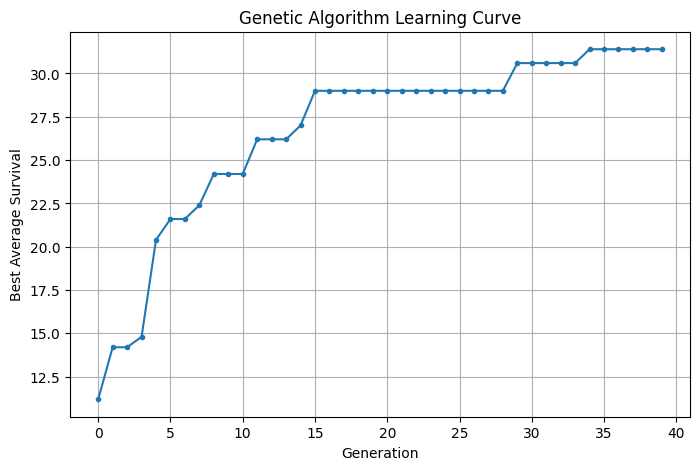

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_scores,
    marker="o",
    markersize=3
)

plt.xlabel("Generation")
plt.ylabel("Best Average Survival")
plt.title(
    "Genetic Algorithm Learning Curve"
)

plt.grid(True)

plt.show()

In [11]:
print(
    "Final best average survival:",
    round(best_scores[-1], 2),
    "/",
    EPISODE_LEN
)

Final best average survival: 31.4 / 40
